In [2]:
import pandas as pd

# Load the CSV files
train_annotations = pd.read_csv('/Users/sanchitthakur/Desktop/real_major/PA-100K/train.csv')
val_annotations = pd.read_csv('/Users/sanchitthakur/Desktop/real_major/PA-100K/val.csv')
test_annotations = pd.read_csv('/Users/sanchitthakur/Desktop/real_major/PA-100K/test.csv')

# Display the first few rows of the training annotations
print(train_annotations.head())


        Image  Female  AgeOver60  Age18-60  AgeLess18  Front  Side  Back  Hat  \
0  000001.jpg       1          0         1          0      1     0     0    0   
1  000002.jpg       0          0         1          0      0     0     1    0   
2  000003.jpg       1          0         1          0      0     1     0    0   
3  000004.jpg       0          0         1          0      0     0     1    0   
4  000005.jpg       1          0         1          0      0     1     0    0   

   Glasses  ...  UpperLogo  UpperPlaid  UpperSplice  LowerStripe  \
0        0  ...          0           0            0            0   
1        0  ...          0           0            0            0   
2        0  ...          1           0            0            0   
3        0  ...          0           0            0            0   
4        0  ...          0           0            0            0   

   LowerPattern  LongCoat  Trousers  Shorts  Skirt&Dress  boots  
0             0         0         1   

In [5]:
!pip install opencv-python


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 MB 5.0 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
anceled

[notice] A new release of pip is available: 24.2 -> 25.0
[notice] To update, run: python3.11 -m pip install --upgrade pip
ERROR: Operation cancelled by user


In [ ]:
import cv2
import os

# Path to the image
image_path = os.path.join('data', 'image_00001.jpg')

# Load the image
image = cv2.imread(image_path)

# Display the image shape
print(image.shape)


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np
import os


In [8]:
# Print the column names of the training annotations DataFrame
print(train_annotations.columns)


Index(['Image', 'Female', 'AgeOver60', 'Age18-60', 'AgeLess18', 'Front',
       'Side', 'Back', 'Hat', 'Glasses', 'HandBag', 'ShoulderBag', 'Backpack',
       'HoldObjectsInFront', 'ShortSleeve', 'LongSleeve', 'UpperStride',
       'UpperLogo', 'UpperPlaid', 'UpperSplice', 'LowerStripe', 'LowerPattern',
       'LongCoat', 'Trousers', 'Shorts', 'Skirt&Dress', 'boots'],
      dtype='object')


In [9]:
# Define paths
train_csv_path = '/Users/sanchitthakur/Desktop/real_major/PA-100K/train.csv'
val_csv_path = '/Users/sanchitthakur/Desktop/real_major/PA-100K/val.csv'
test_csv_path = '/Users/sanchitthakur/Desktop/real_major/PA-100K/test.csv'
image_dir = 'PA-100K/data'

# Load annotations
train_annotations = pd.read_csv(train_csv_path)
val_annotations = pd.read_csv(val_csv_path)
test_annotations = pd.read_csv(test_csv_path)

# Define image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Create data generators with augmentation
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2)
val_test_datagen = ImageDataGenerator(rescale=1./255)

def create_generator(datagen, annotations, image_dir):
    generator = datagen.flow_from_dataframe(
        dataframe=annotations,
        directory=image_dir,
        x_col='Image',  # Correct column name for image IDs
        y_col=annotations.columns[1:],
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='raw'
    )
    return generator

train_generator = create_generator(train_datagen, train_annotations, image_dir)
val_generator = create_generator(val_test_datagen, val_annotations, image_dir)
test_generator = create_generator(val_test_datagen, test_annotations, image_dir)


Found 80000 validated image filenames.
Found 10000 validated image filenames.
Found 10000 validated image filenames.


In [13]:
from tensorflow.keras.callbacks import EarlyStopping

def create_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(16, (3, 3), activation='relu', input_shape=input_shape),  # Reduced filters
        MaxPooling2D((2, 2)),
        Conv2D(32, (3, 3), activation='relu'),  # Reduced filters
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),  # Reduced neurons
        Dropout(0.5),
        Dense(num_classes, activation='sigmoid')  # Sigmoid for multi-label classification
    ])
    return model

input_shape = IMG_SIZE + (3,)
num_classes = len(train_annotations.columns) - 1  # Number of attributes
model = create_model(input_shape, num_classes)

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [15]:
# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [17]:
# Train the model with early stopping
history = model.fit(
    train_generator,
    epochs=3,  # Increased epochs to allow early stopping to work
    validation_data=val_generator,
    callbacks=[early_stopping]
)

Epoch 1/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 745s 298ms/step - accuracy: 0.4211 - loss: 0.3083 - val_accuracy: 0.3863 - val_loss: 0.3385
Epoch 2/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 750s 300ms/step - accuracy: 0.4127 - loss: 0.3047 - val_accuracy: 0.3371 - val_loss: 0.3314
Epoch 3/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 755s 302ms/step - accuracy: 0.4097 - loss: 0.3029 - val_accuracy: 0.3026 - val_loss: 0.3282


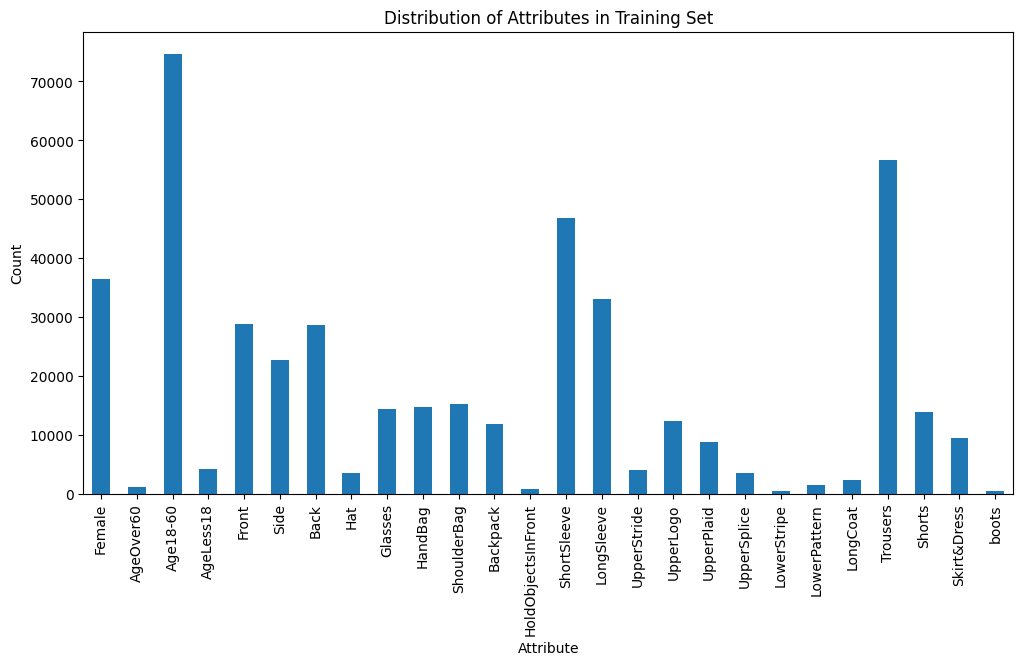

In [18]:
import matplotlib.pyplot as plt

# Plot the distribution of each attribute
attribute_counts = train_annotations.drop(columns=['Image']).sum()
attribute_counts.plot(kind='bar', figsize=(12, 6))
plt.title('Distribution of Attributes in Training Set')
plt.xlabel('Attribute')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()


/opt/homebrew/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step


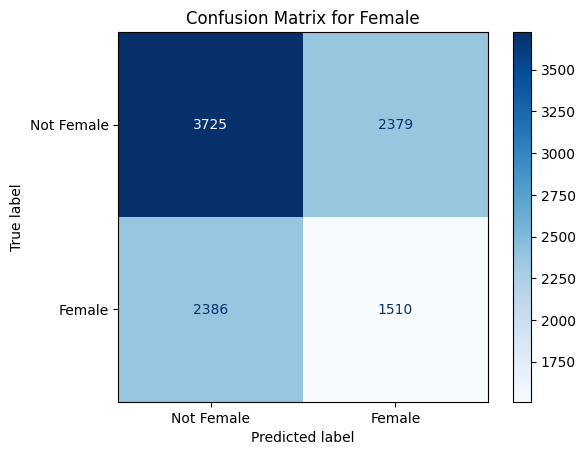

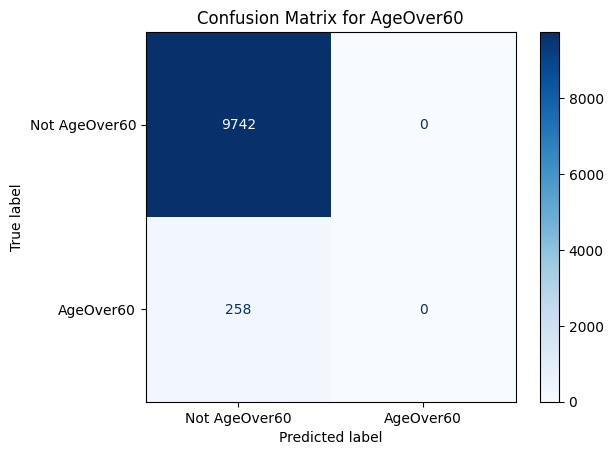

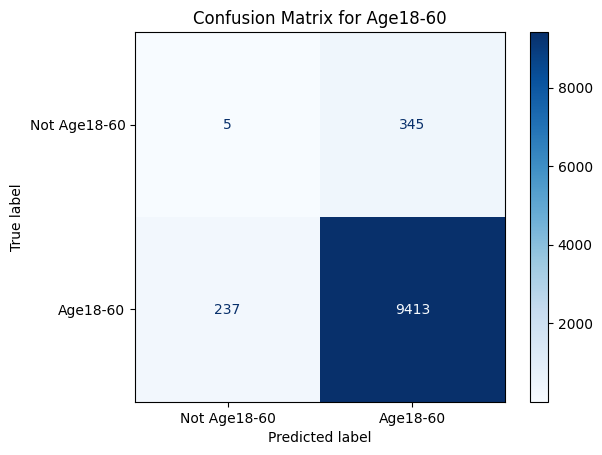

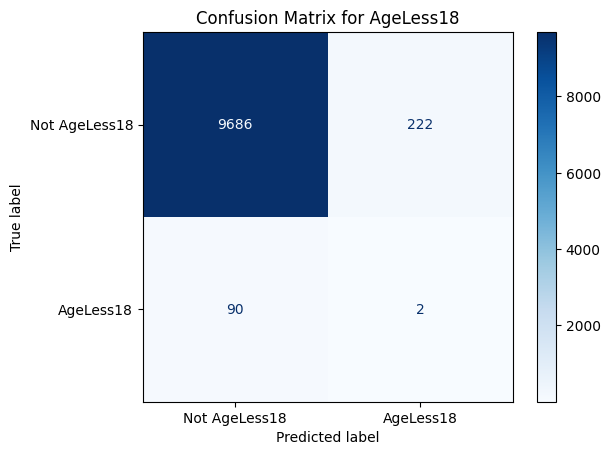

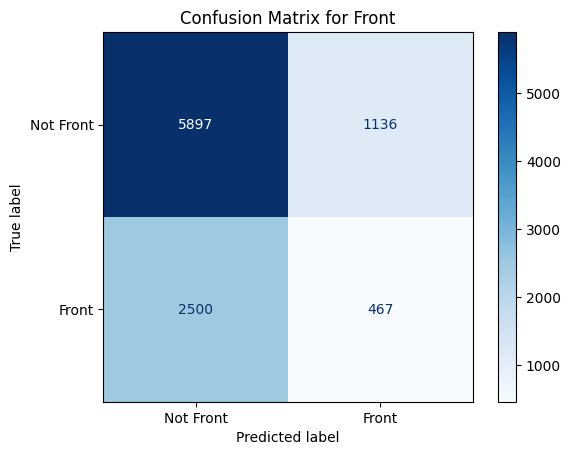

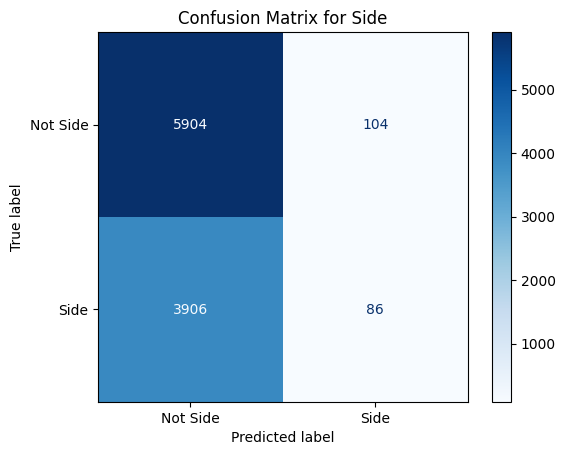

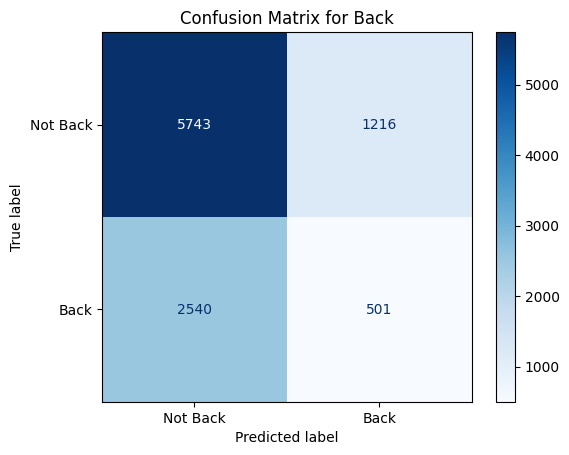

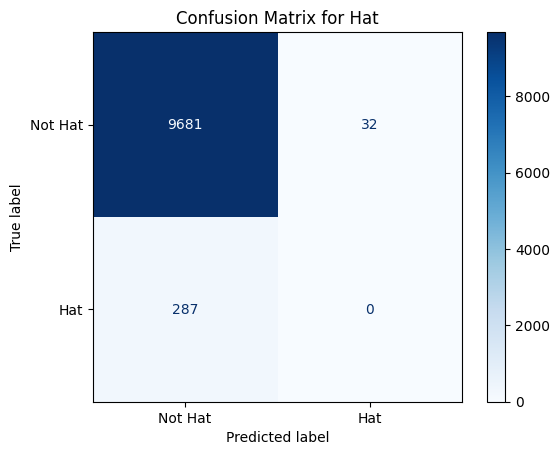

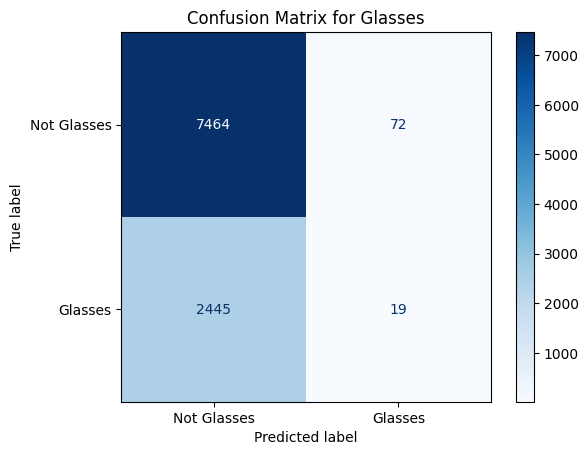

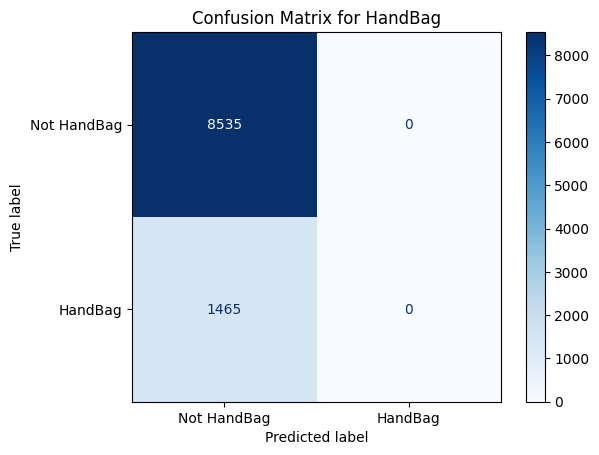

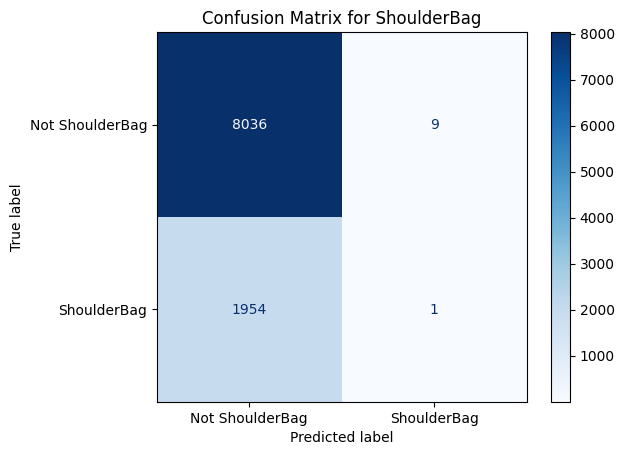

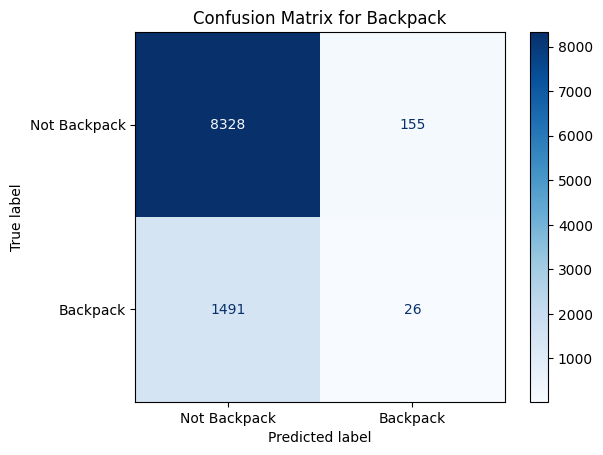

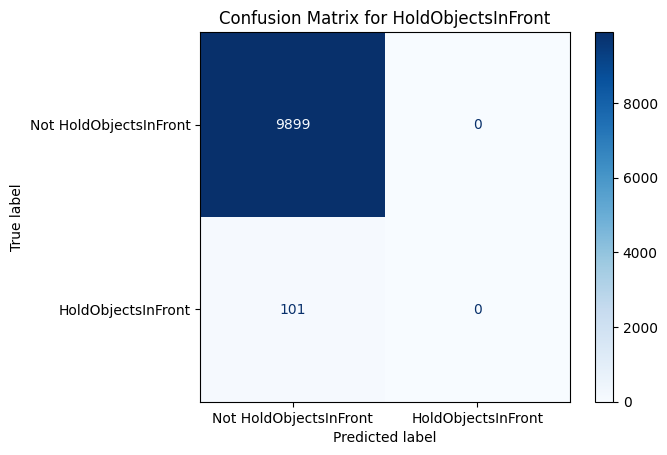

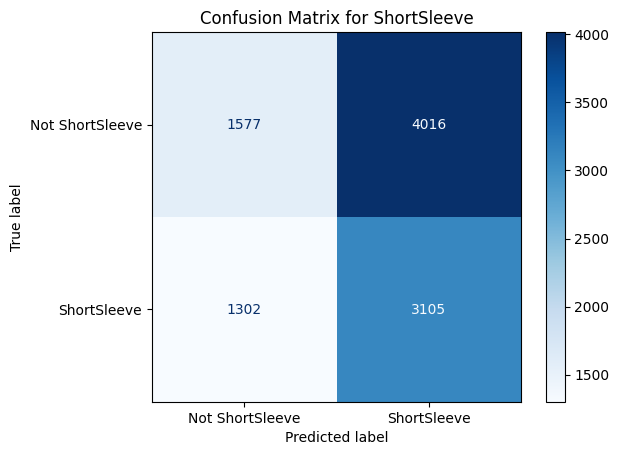

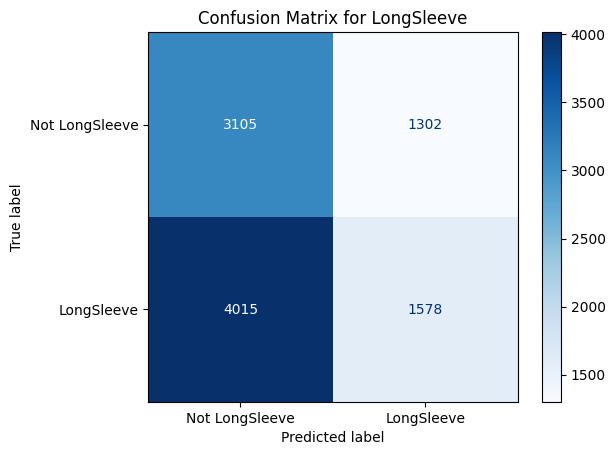

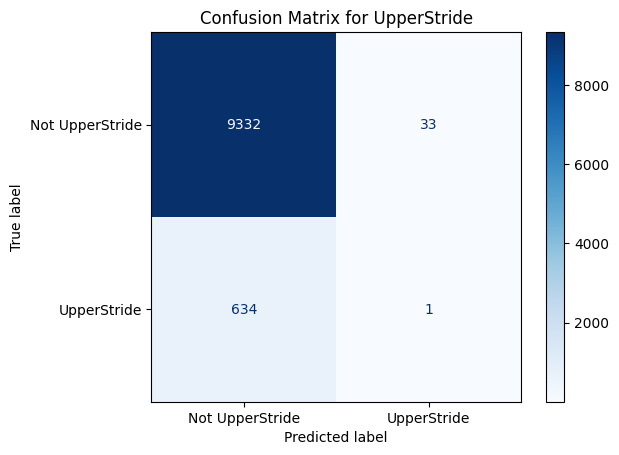

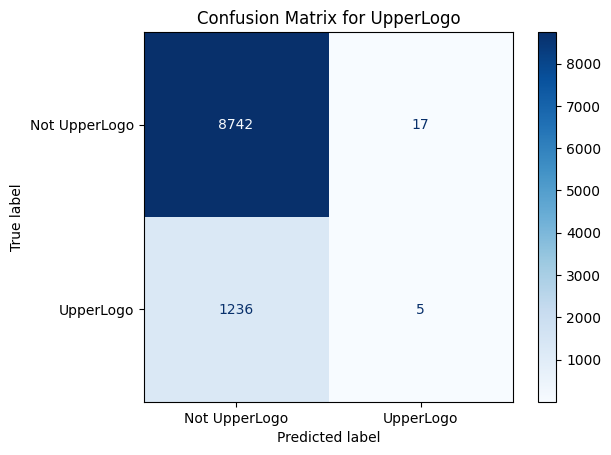

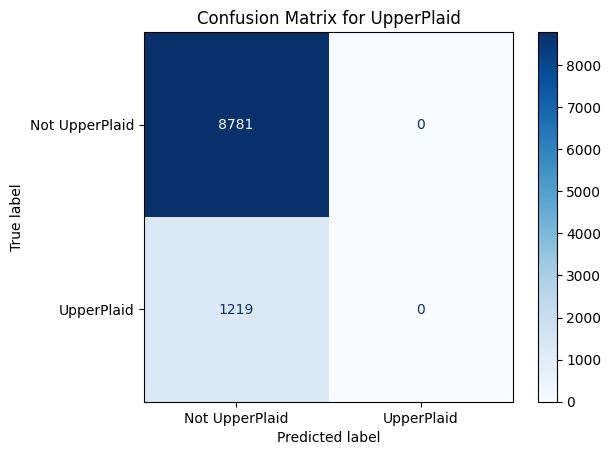

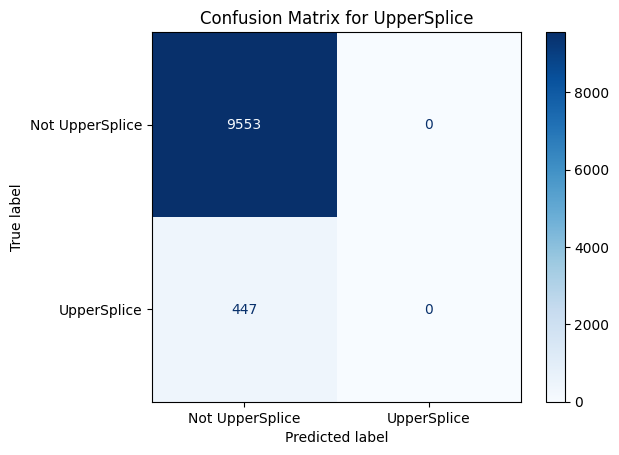

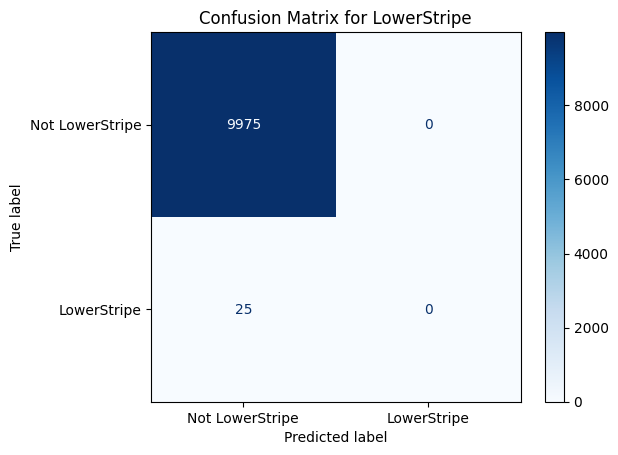

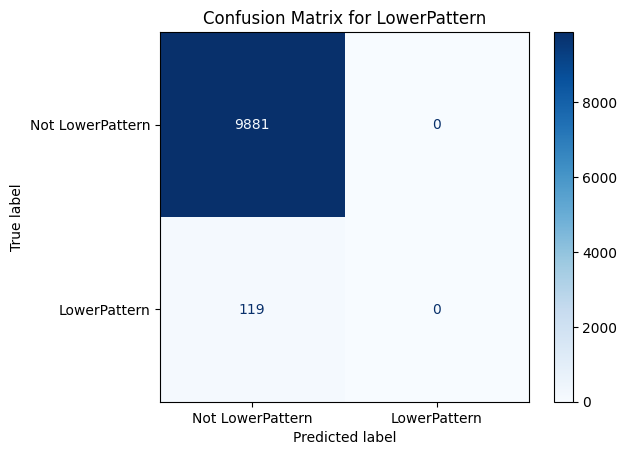

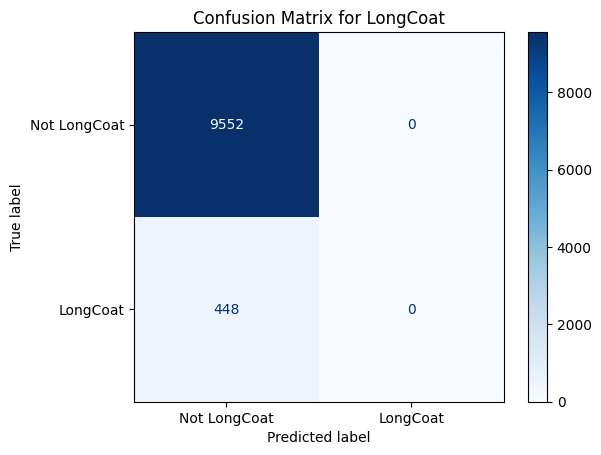

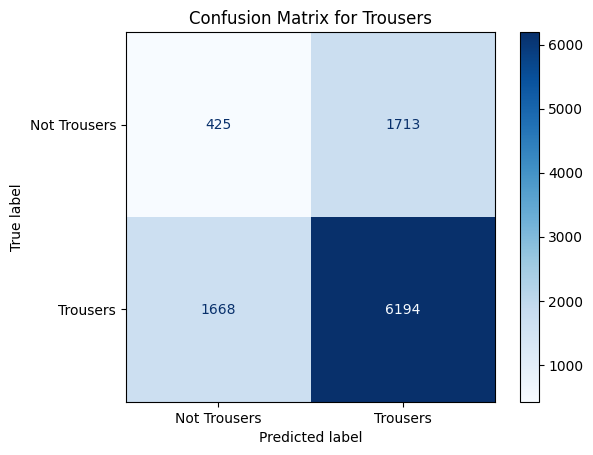

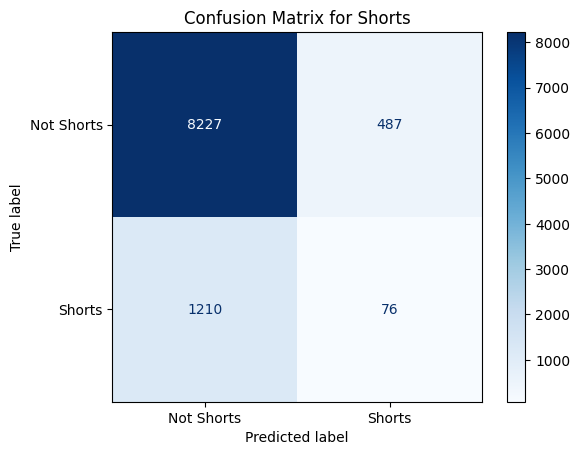

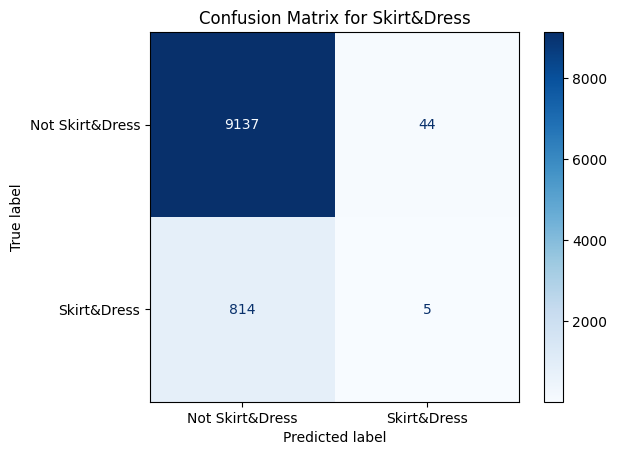

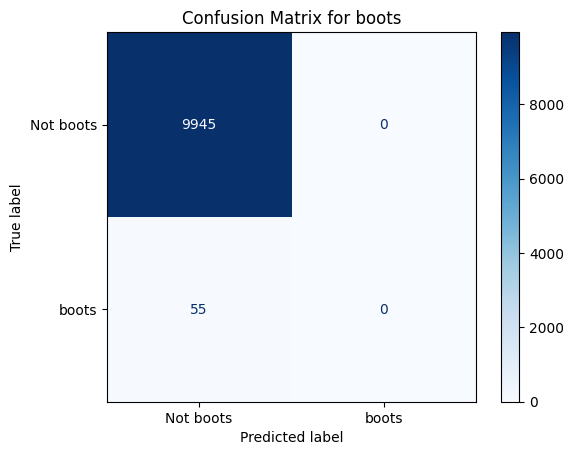

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Make predictions on the test set
test_predictions = model.predict(test_generator)
test_predictions = (test_predictions > 0.5).astype(int)  # Threshold predictions

# Get true labels
true_labels = test_annotations.drop(columns=['Image']).values

# Plot confusion matrix for each attribute
for i, attribute in enumerate(train_annotations.columns[1:]):
    cm = confusion_matrix(true_labels[:, i], test_predictions[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not ' + attribute, attribute])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix for {attribute}')
    plt.show()


In [20]:
model.save('pedestrian_attribute_model.h5')
